In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import random

In [2]:
data = pd.read_csv(r"C:\Users\tusha\Desktop\ML\project elec demand\electricity demand dataset.csv")

In [3]:
data

,Timestamp,hour,dayofweek,month,year,dayofyear,Temperature,Humidity,Demand
0,01-Jan-20,0.0,2.0,1.0,2020.0,1.0,3.000000,61.288951,2457.119872
1,01-Jan-20,1.0,2.0,1.0,2020.0,1.0,3.000000,52.873702,2269.904712
2,01-Jan-20,2.0,2.0,1.0,2020.0,1.0,4.244482,36.341783,2215.640403
3,01-Jan-20,3.0,2.0,1.0,2020.0,1.0,3.000000,72.629378,2174.232413
4,01-Jan-20,4.0,2.0,1.0,2020.0,1.0,3.881208,90.582444,2472.453006
...,...,...,...,...,...,...,...,...,...
43843,31-Dec-24,19.0,1.0,12.0,2024.0,366.0,3.956838,43.287161,4689.693109
43844,31-Dec-24,20.0,1.0,12.0,2024.0,366.0,3.118824,51.705756,4331.249224
43845,31-Dec-24,21.0,1.0,12.0,2024.0,366.0,3.000000,40.565916,4015.979957
43846,31-Dec-24,22.0,1.0,12.0,2024.0,366.0,3.000000,51.998107,3353.241682


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43848 entries, 0 to 43847
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Timestamp    43848 non-null  object 
 1   hour         43837 non-null  float64
 2   dayofweek    43839 non-null  float64
 3   month        43840 non-null  float64
 4   year         43843 non-null  float64
 5   dayofyear    43843 non-null  float64
 6   Temperature  43841 non-null  float64
 7   Humidity     43838 non-null  float64
 8   Demand       43841 non-null  float64
dtypes: float64(8), object(1)
memory usage: 3.0+ MB


In [6]:
# Convert the 'Timestamp' column datatype to datetime format

data['Timestamp']=pd.to_datetime(data['Timestamp'], format='mixed')

In [7]:
# Set the 'Timestamp' column as DataFrame's index

data = data.set_index('Timestamp')

In [8]:
# Using Describe function to check the summary statistics

data[['Temperature', 'Humidity', 'Demand']].describe()

,Temperature,Humidity,Demand
count,43841.000000,43838.000000,43841.000000
mean,25.067788,59.903007,5000.790976
std,12.821725,18.342604,1412.527409
min,3.000000,20.000000,1611.954020
25%,15.210186,46.241224,4015.668472
50%,25.003212,59.986720,5013.053367
75%,34.740971,73.796820,6000.803082
max,50.000000,95.000000,11910.705100


In [9]:
# Check for Missing Values

data.isnull().sum()

hour           11
dayofweek       9
month           8
year            5
dayofyear       5
Temperature     7
Humidity       10
Demand          7
dtype: int64

In [10]:
# To show the records that contain All null values

data[data.isna().all(axis=1)]

,hour,dayofweek,month,year,dayofyear,Temperature,Humidity,Demand
Timestamp,,,,,,,,
2021-02-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-02-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-02-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-02-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
# Drop those rows that contain All missing values

data = data.dropna(how = 'all')
data

,hour,dayofweek,month,year,dayofyear,Temperature,Humidity,Demand
Timestamp,,,,,,,,
2020-01-01,0.0,2.0,1.0,2020.0,1.0,3.000000,61.288951,2457.119872
2020-01-01,1.0,2.0,1.0,2020.0,1.0,3.000000,52.873702,2269.904712
2020-01-01,2.0,2.0,1.0,2020.0,1.0,4.244482,36.341783,2215.640403
2020-01-01,3.0,2.0,1.0,2020.0,1.0,3.000000,72.629378,2174.232413
2020-01-01,4.0,2.0,1.0,2020.0,1.0,3.881208,90.582444,2472.453006
...,...,...,...,...,...,...,...,...
2024-12-31,19.0,1.0,12.0,2024.0,366.0,3.956838,43.287161,4689.693109
2024-12-31,20.0,1.0,12.0,2024.0,366.0,3.118824,51.705756,4331.249224
2024-12-31,21.0,1.0,12.0,2024.0,366.0,3.000000,40.565916,4015.979957


In [12]:
# Check for Missing Values
data.isnull().sum()

hour           7
dayofweek      5
month          4
year           1
dayofyear      1
Temperature    3
Humidity       6
Demand         3
dtype: int64

In [13]:
# Applying 'ffill' method on columns

data[['hour', 'dayofweek', 'month', 'year', 'dayofyear']] = data[['hour', 'dayofweek', 'month', 'year', 'dayofyear']].ffill()

In [14]:
# Applying 'bfill' method on columns

data[['Temperature', 'Humidity']] = data[['Temperature', 'Humidity']].bfill()

In [15]:
# Applying 'interpolate' method on columns

data['Demand'] = data['Demand'].interpolate(method = 'time')

hour           0
dayofweek      0
month          0
year           0
dayofyear      0
Temperature    0
Humidity       0
Demand         0
dtype: int64

In [28]:
# Create the 'Quarter' column at 5th index in the dataset

data.insert(5, 'quarter', data.index.quarter)

In [29]:
data

,hour,dayofweek,month,year,dayofyear,quarter,Temperature,Humidity,Demand
Timestamp,,,,,,,,,
2020-01-01,0.0,2.0,1.0,2020.0,1.0,1,3.000000,61.288951,2457.119872
2020-01-01,1.0,2.0,1.0,2020.0,1.0,1,3.000000,52.873702,2269.904712
2020-01-01,2.0,2.0,1.0,2020.0,1.0,1,4.244482,36.341783,2215.640403
2020-01-01,3.0,2.0,1.0,2020.0,1.0,1,3.000000,72.629378,2174.232413
2020-01-01,4.0,2.0,1.0,2020.0,1.0,1,3.881208,90.582444,2472.453006
...,...,...,...,...,...,...,...,...,...
2024-12-31,19.0,1.0,12.0,2024.0,366.0,4,3.956838,43.287161,4689.693109
2024-12-31,20.0,1.0,12.0,2024.0,366.0,4,3.118824,51.705756,4331.249224
2024-12-31,21.0,1.0,12.0,2024.0,366.0,4,3.000000,40.565916,4015.979957


In [30]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 43844 entries, 2020-01-01 to 2024-12-31
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   hour         43844 non-null  float64
 1   dayofweek    43844 non-null  float64
 2   month        43844 non-null  float64
 3   year         43844 non-null  float64
 4   dayofyear    43844 non-null  float64
 5   quarter      43844 non-null  int32  
 6   Temperature  43844 non-null  float64
 7   Humidity     43844 non-null  float64
 8   Demand       43844 non-null  float64
dtypes: float64(8), int32(1)
memory usage: 3.2 MB


In [31]:
# Convert the datatype from float to integer of columns

data[['hour', 'dayofweek', 'month','year', 'dayofyear']] = data[['hour', 'dayofweek', 'month','year', 'dayofyear']].astype(int)

In [32]:
# Create the 'Week of Year' column at 5th index in the dataset

data.insert(5, 'weekofyear', data.index.isocalendar().week.astype(int))

In [33]:
data

,hour,dayofweek,month,year,dayofyear,weekofyear,quarter,Temperature,Humidity,Demand
Timestamp,,,,,,,,,,
2020-01-01,0,2,1,2020,1,1,1,3.000000,61.288951,2457.119872
2020-01-01,1,2,1,2020,1,1,1,3.000000,52.873702,2269.904712
2020-01-01,2,2,1,2020,1,1,1,4.244482,36.341783,2215.640403
2020-01-01,3,2,1,2020,1,1,1,3.000000,72.629378,2174.232413
2020-01-01,4,2,1,2020,1,1,1,3.881208,90.582444,2472.453006
...,...,...,...,...,...,...,...,...,...,...
2024-12-31,19,1,12,2024,366,1,4,3.956838,43.287161,4689.693109
2024-12-31,20,1,12,2024,366,1,4,3.118824,51.705756,4331.249224
2024-12-31,21,1,12,2024,366,1,4,3.000000,40.565916,4015.979957


In [ ]:
# Create a new column at 7th index to check the Weekend

data.insert(7, 'is_weekend', data.index.dayofweek.isin([5,6]))

In [36]:
# Convert the datatype from float to integer of the column

data['is_weekend'] = data['is_weekend'].astype(int)

In [37]:
data

,hour,dayofweek,month,year,dayofyear,weekofyear,quarter,is_weekend,Temperature,Humidity,Demand
Timestamp,,,,,,,,,,,
2020-01-01,0,2,1,2020,1,1,1,0,3.000000,61.288951,2457.119872
2020-01-01,1,2,1,2020,1,1,1,0,3.000000,52.873702,2269.904712
2020-01-01,2,2,1,2020,1,1,1,0,4.244482,36.341783,2215.640403
2020-01-01,3,2,1,2020,1,1,1,0,3.000000,72.629378,2174.232413
2020-01-01,4,2,1,2020,1,1,1,0,3.881208,90.582444,2472.453006
...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31,19,1,12,2024,366,1,4,0,3.956838,43.287161,4689.693109
2024-12-31,20,1,12,2024,366,1,4,0,3.118824,51.705756,4331.249224
2024-12-31,21,1,12,2024,366,1,4,0,3.000000,40.565916,4015.979957


In [38]:
# import Holidays package

import holidays

In [39]:
# create a new column that will show holidays, otherwise NaN

data['Holidays'] = holidays.IN(years = data.year)

In [40]:
# using value_counts() to check the holidays with their count/occurance

data.Holidays.value_counts()   #1 holiday per year × 24 hours × 5 years = 120 rows

Holidays
Republic Day          120
Maha Shivaratri       120
Mahavir Jayanti       120
Good Friday           120
Buddha Purnima        120
Id-ul-Fitr            120
Bakrid                120
Janmashtami           120
Independence Day      120
Muharram              120
Gandhi Jayanti        120
Dussehra              120
Milad-un-Nabi         120
Diwali                120
Guru Nanak Jayanti    120
Christmas             120
Name: count, dtype: int64

In [41]:
# deleting the 'Holidays' column from the dataframe

data = data.drop('Holidays', axis=1)

In [42]:
# Create a new column that will contain Demand from the same hour yesterday

data['Demand_lag_24hr'] = data['Demand'].shift(24)

In [43]:
# Create a new column that will contain Demand from the same hour last week

data['demand_lag_168hr'] = data['Demand'].shift(168) # 24x7 = 168 hours for weekly shift

In [45]:
# show top rows of the dataframe

data.head(50)

,hour,dayofweek,month,year,dayofyear,weekofyear,quarter,is_weekend,Temperature,Humidity,Demand,Demand_lag_24hr,demand_lag_168hr
Timestamp,,,,,,,,,,,,,
2020-01-01,0,2,1,2020,1,1,1,0,3.000000,61.288951,2457.119872,NaN,NaN
2020-01-01,1,2,1,2020,1,1,1,0,3.000000,52.873702,2269.904712,NaN,NaN
2020-01-01,2,2,1,2020,1,1,1,0,4.244482,36.341783,2215.640403,NaN,NaN
2020-01-01,3,2,1,2020,1,1,1,0,3.000000,72.629378,2174.232413,NaN,NaN
2020-01-01,4,2,1,2020,1,1,1,0,3.881208,90.582444,2472.453006,NaN,NaN
2020-01-01,5,2,1,2020,1,1,1,0,10.822571,67.753433,3104.845505,NaN,NaN
2020-01-01,6,2,1,2020,1,1,1,0,6.306673,94.912591,3759.476912,NaN,NaN
2020-01-01,7,2,1,2020,1,1,1,0,7.464640,74.456860,4114.486001,NaN,NaN
2020-01-01,8,2,1,2020,1,1,1,0,14.746876,66.725005,4575.159503,NaN,NaN


In [46]:
# using iloc function for the slicing of dataframe' rows

data.iloc[160:200]

,hour,dayofweek,month,year,dayofyear,weekofyear,quarter,is_weekend,Temperature,Humidity,Demand,Demand_lag_24hr,demand_lag_168hr
Timestamp,,,,,,,,,,,,,
2020-01-07,16,1,1,2020,7,2,1,0,14.016616,37.637752,4587.785143,4733.816549,NaN
2020-01-07,17,1,1,2020,7,2,1,0,6.736632,54.734906,4833.704288,4796.039663,NaN
2020-01-07,18,1,1,2020,7,2,1,0,17.782435,49.297649,5400.257796,4791.518998,NaN
2020-01-07,19,1,1,2020,7,2,1,0,3.000000,37.696671,4424.534926,4492.165854,NaN
2020-01-07,20,1,1,2020,7,2,1,0,7.116704,46.152197,4279.454320,4398.302015,NaN
2020-01-07,21,1,1,2020,7,2,1,0,5.158936,44.385460,3768.807077,3705.698515,NaN
2020-01-07,22,1,1,2020,7,2,1,0,3.000000,46.821530,2924.189540,3211.918549,NaN
2020-01-07,23,1,1,2020,7,2,1,0,3.000000,44.708096,2657.653050,2857.968639,NaN
2020-01-08,0,2,1,2020,8,2,1,0,3.000000,47.891592,2363.060115,2216.875986,2457.119872


In [47]:
# Create a new column that will contain Rolling Mean of the Demand in last 24 hours

data['demand_rolling_mean_24hr'] = data['Demand'].rolling(window=24).mean()

In [48]:
# Create a new column that will contain Rolling Standard Deviation of the Demand in last 24 hours

data['demand_rolling_std_24hr'] = data['Demand'].rolling(window=24).std()

In [49]:
# show top rows of the dataframe

data.head(27)

,hour,dayofweek,month,year,dayofyear,weekofyear,quarter,is_weekend,Temperature,Humidity,Demand,Demand_lag_24hr,demand_lag_168hr,demand_rolling_mean_24hr,demand_rolling_std_24hr
Timestamp,,,,,,,,,,,,,,,
2020-01-01,0,2,1,2020,1,1,1,0,3.000000,61.288951,2457.119872,NaN,NaN,NaN,NaN
2020-01-01,1,2,1,2020,1,1,1,0,3.000000,52.873702,2269.904712,NaN,NaN,NaN,NaN
2020-01-01,2,2,1,2020,1,1,1,0,4.244482,36.341783,2215.640403,NaN,NaN,NaN,NaN
2020-01-01,3,2,1,2020,1,1,1,0,3.000000,72.629378,2174.232413,NaN,NaN,NaN,NaN
2020-01-01,4,2,1,2020,1,1,1,0,3.881208,90.582444,2472.453006,NaN,NaN,NaN,NaN
2020-01-01,5,2,1,2020,1,1,1,0,10.822571,67.753433,3104.845505,NaN,NaN,NaN,NaN
2020-01-01,6,2,1,2020,1,1,1,0,6.306673,94.912591,3759.476912,NaN,NaN,NaN,NaN
2020-01-01,7,2,1,2020,1,1,1,0,7.464640,74.456860,4114.486001,NaN,NaN,NaN,NaN
2020-01-01,8,2,1,2020,1,1,1,0,14.746876,66.725005,4575.159503,NaN,NaN,NaN,NaN


In [50]:
# Drop all Rows having null values

data = data.dropna()
data

,hour,dayofweek,month,year,dayofyear,weekofyear,quarter,is_weekend,Temperature,Humidity,Demand,Demand_lag_24hr,demand_lag_168hr,demand_rolling_mean_24hr,demand_rolling_std_24hr
Timestamp,,,,,,,,,,,,,,,
2020-01-08,0,2,1,2020,8,2,1,0,3.000000,47.891592,2363.060115,2216.875986,2457.119872,3857.890516,1007.130968
2020-01-08,1,2,1,2020,8,2,1,0,4.433666,61.209727,2282.558766,2400.102433,2269.904712,3852.992863,1014.785101
2020-01-08,2,2,1,2020,8,2,1,0,5.000529,63.868618,2193.324174,2493.107375,2215.640403,3840.501897,1033.916351
2020-01-08,3,2,1,2020,8,2,1,0,4.253477,44.603210,2208.724679,2241.451559,2174.232413,3839.138277,1036.136212
2020-01-08,4,2,1,2020,8,2,1,0,5.966044,85.921008,2402.611018,2406.161001,2472.453006,3838.990361,1036.349905
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31,19,1,12,2024,366,1,4,0,3.956838,43.287161,4689.693109,5102.077310,5105.730509,4039.969992,976.961312
2024-12-31,20,1,12,2024,366,1,4,0,3.118824,51.705756,4331.249224,4187.844204,4673.672173,4045.945201,978.342615
2024-12-31,21,1,12,2024,366,1,4,0,3.000000,40.565916,4015.979957,3859.260701,3856.359014,4052.475170,977.565114


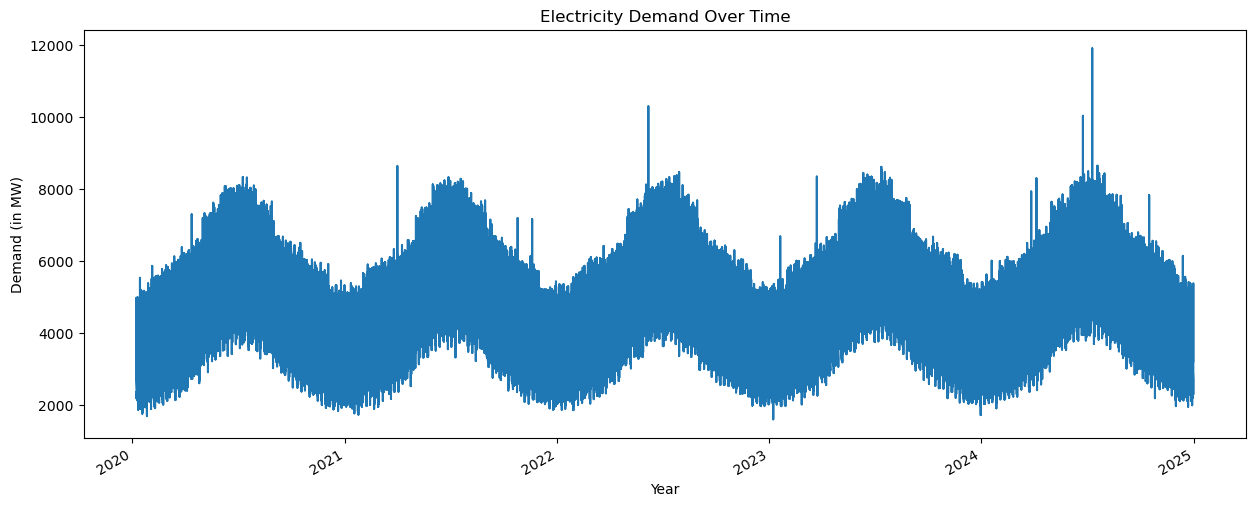

In [51]:
# Plot raw demand over time

data['Demand'].plot(figsize =(15,6), title = "Electricity Demand Over Time")
plt.xlabel("Year")                          # naming for x-axis
plt.ylabel("Demand (in MW)")                # naming for y-axis  
                   
plt.show()

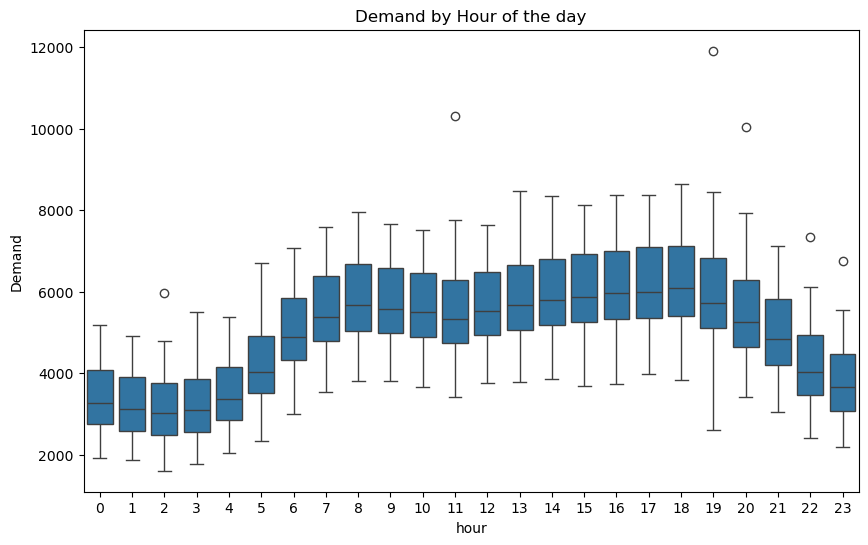

In [55]:
# Visualize demand by hour of day, using boxplot

plt.figure(figsize = (10,6))
sns.boxplot(data = data, x = 'hour', y = 'Demand')
plt.title("Demand by Hour of the day");
plt.show()

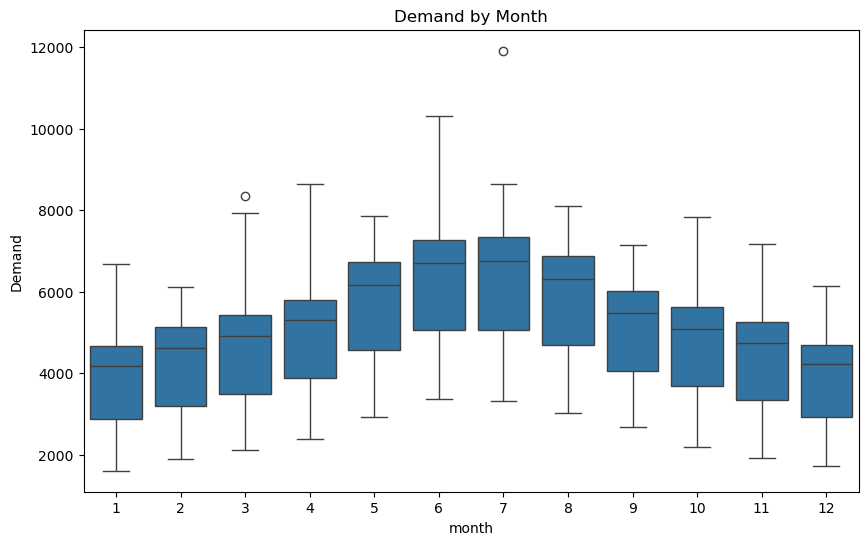

In [56]:
# Visualize demand by month, using boxplot

plt.figure(figsize=(10,6))
sns.boxplot(data = data, x = 'month', y = 'Demand')
plt.title("Demand by Month")
plt.show()

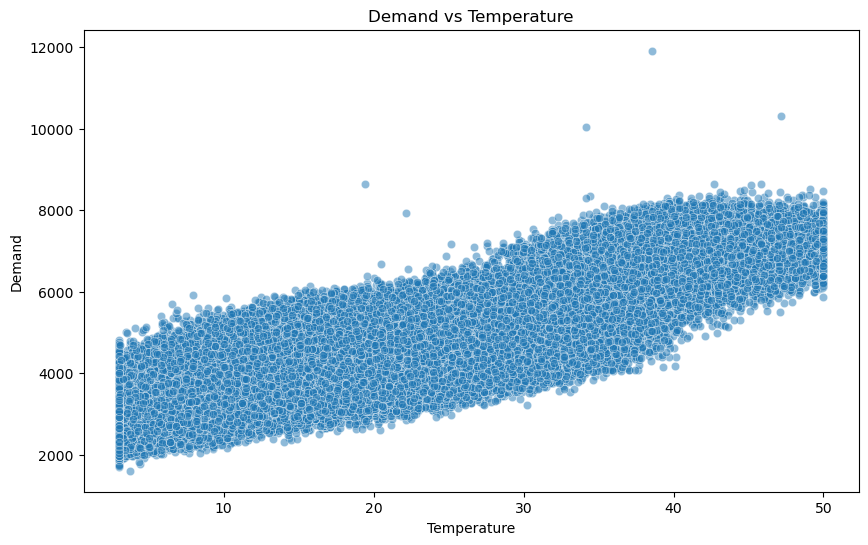

In [57]:
# Scatter plot of Demand vs. Temperature

plt.figure(figsize=(10,6))
sns.scatterplot(data = data, x = 'Temperature', y = 'Demand', alpha = 0.5)  #alpha - to adjust the tranparency of points
plt.title("Demand vs Temperature")
plt.show()

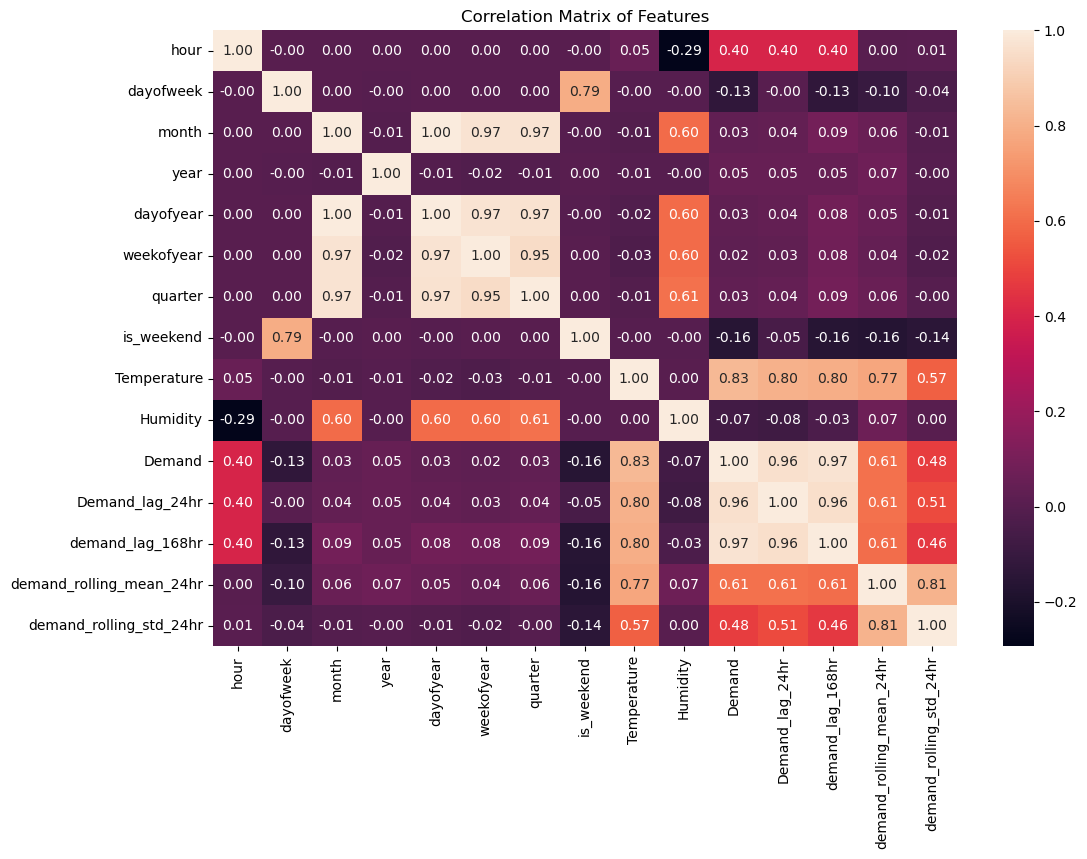

In [58]:
# Correlation Matrix and Heatmap

plt.figure(figsize=(12,8))
sns.heatmap(data.corr(), annot = True, fmt=".2f") # anoot=True : to show the numbers , fmt : to adjust decimals
plt.title("Correlation Matrix of Features")
plt.show()

In [59]:
data

,hour,dayofweek,month,year,dayofyear,weekofyear,quarter,is_weekend,Temperature,Humidity,Demand,Demand_lag_24hr,demand_lag_168hr,demand_rolling_mean_24hr,demand_rolling_std_24hr
Timestamp,,,,,,,,,,,,,,,
2020-01-08,0,2,1,2020,8,2,1,0,3.000000,47.891592,2363.060115,2216.875986,2457.119872,3857.890516,1007.130968
2020-01-08,1,2,1,2020,8,2,1,0,4.433666,61.209727,2282.558766,2400.102433,2269.904712,3852.992863,1014.785101
2020-01-08,2,2,1,2020,8,2,1,0,5.000529,63.868618,2193.324174,2493.107375,2215.640403,3840.501897,1033.916351
2020-01-08,3,2,1,2020,8,2,1,0,4.253477,44.603210,2208.724679,2241.451559,2174.232413,3839.138277,1036.136212
2020-01-08,4,2,1,2020,8,2,1,0,5.966044,85.921008,2402.611018,2406.161001,2472.453006,3838.990361,1036.349905
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31,19,1,12,2024,366,1,4,0,3.956838,43.287161,4689.693109,5102.077310,5105.730509,4039.969992,976.961312
2024-12-31,20,1,12,2024,366,1,4,0,3.118824,51.705756,4331.249224,4187.844204,4673.672173,4045.945201,978.342615
2024-12-31,21,1,12,2024,366,1,4,0,3.000000,40.565916,4015.979957,3859.260701,3856.359014,4052.475170,977.565114


In [60]:
# Defining Target Variable (Y)

Y = data.Demand                         # target variable / dependent variable

In [61]:
# Defining Features (X)

X = data.drop('Demand', axis=1)         # independent variables / features / predictors

In [62]:
print(Y)           # Target variable

Timestamp
2020-01-08    2363.060115
2020-01-08    2282.558766
2020-01-08    2193.324174
2020-01-08    2208.724679
2020-01-08    2402.611018
                 ...     
2024-12-31    4689.693109
2024-12-31    4331.249224
2024-12-31    4015.979957
2024-12-31    3353.241682
2024-12-31    3219.023339
Name: Demand, Length: 43676, dtype: float64


In [63]:
X

,hour,dayofweek,month,year,dayofyear,weekofyear,quarter,is_weekend,Temperature,Humidity,Demand_lag_24hr,demand_lag_168hr,demand_rolling_mean_24hr,demand_rolling_std_24hr
Timestamp,,,,,,,,,,,,,,
2020-01-08,0,2,1,2020,8,2,1,0,3.000000,47.891592,2216.875986,2457.119872,3857.890516,1007.130968
2020-01-08,1,2,1,2020,8,2,1,0,4.433666,61.209727,2400.102433,2269.904712,3852.992863,1014.785101
2020-01-08,2,2,1,2020,8,2,1,0,5.000529,63.868618,2493.107375,2215.640403,3840.501897,1033.916351
2020-01-08,3,2,1,2020,8,2,1,0,4.253477,44.603210,2241.451559,2174.232413,3839.138277,1036.136212
2020-01-08,4,2,1,2020,8,2,1,0,5.966044,85.921008,2406.161001,2472.453006,3838.990361,1036.349905
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31,19,1,12,2024,366,1,4,0,3.956838,43.287161,5102.077310,5105.730509,4039.969992,976.961312
2024-12-31,20,1,12,2024,366,1,4,0,3.118824,51.705756,4187.844204,4673.672173,4045.945201,978.342615
2024-12-31,21,1,12,2024,366,1,4,0,3.000000,40.565916,3859.260701,3856.359014,4052.475170,977.565114


In [64]:
# Splitting the data into Training and Testing data

X_train = X.loc[ : '2023-12-31']                  # taking 80% of data as training data

In [65]:
X_train

,hour,dayofweek,month,year,dayofyear,weekofyear,quarter,is_weekend,Temperature,Humidity,Demand_lag_24hr,demand_lag_168hr,demand_rolling_mean_24hr,demand_rolling_std_24hr
Timestamp,,,,,,,,,,,,,,
2020-01-08,0,2,1,2020,8,2,1,0,3.000000,47.891592,2216.875986,2457.119872,3857.890516,1007.130968
2020-01-08,1,2,1,2020,8,2,1,0,4.433666,61.209727,2400.102433,2269.904712,3852.992863,1014.785101
2020-01-08,2,2,1,2020,8,2,1,0,5.000529,63.868618,2493.107375,2215.640403,3840.501897,1033.916351
2020-01-08,3,2,1,2020,8,2,1,0,4.253477,44.603210,2241.451559,2174.232413,3839.138277,1036.136212
2020-01-08,4,2,1,2020,8,2,1,0,5.966044,85.921008,2406.161001,2472.453006,3838.990361,1036.349905
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-31,19,6,12,2023,365,52,4,1,6.721774,46.627264,3894.908251,3840.654680,3597.790591,879.089476
2023-12-31,20,6,12,2023,365,52,4,1,7.557696,58.505012,3797.287793,4122.218903,3599.126925,879.430235
2023-12-31,21,6,12,2023,365,52,4,1,3.000000,48.001079,3280.602315,3307.887152,3604.785551,877.726873


In [66]:
Y_train = Y.loc[ : '2023-12-31' ]             # taking 80% of data as training data

In [67]:
Y_train

Timestamp
2020-01-08    2363.060115
2020-01-08    2282.558766
2020-01-08    2193.324174
2020-01-08    2208.724679
2020-01-08    2402.611018
                 ...     
2023-12-31    4185.721624
2023-12-31    3829.359810
2023-12-31    3416.409325
2023-12-31    3188.143951
2023-12-31    2631.860751
Name: Demand, Length: 34892, dtype: float64

In [68]:
X_test = X.loc[ '2024-01-01' : ]               # taking 20% of data as testing data

In [69]:
X_test

,hour,dayofweek,month,year,dayofyear,weekofyear,quarter,is_weekend,Temperature,Humidity,Demand_lag_24hr,demand_lag_168hr,demand_rolling_mean_24hr,demand_rolling_std_24hr
Timestamp,,,,,,,,,,,,,,
2024-01-01,0,0,1,2024,1,1,1,0,3.000000,65.297046,2373.967493,2752.003113,3626.185642,856.204515
2024-01-01,1,0,1,2024,1,1,1,0,3.000000,69.068654,2328.972904,2419.747602,3640.380403,836.357296
2024-01-01,2,0,1,2024,1,1,1,0,3.000000,80.885372,1729.176090,2292.834087,3669.813854,776.458065
2024-01-01,3,0,1,2024,1,1,1,0,7.788675,66.501527,2257.337352,2507.704476,3685.801618,749.595470
2024-01-01,4,0,1,2024,1,1,1,0,6.607828,57.858109,2516.948873,2690.933257,3692.926651,738.736316
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31,19,1,12,2024,366,1,4,0,3.956838,43.287161,5102.077310,5105.730509,4039.969992,976.961312
2024-12-31,20,1,12,2024,366,1,4,0,3.118824,51.705756,4187.844204,4673.672173,4045.945201,978.342615
2024-12-31,21,1,12,2024,366,1,4,0,3.000000,40.565916,3859.260701,3856.359014,4052.475170,977.565114


In [70]:
Y_test = Y.loc[ '2024-01-01' : ]                       # taking 20% of data as testing data

In [71]:
Y_test

Timestamp
2024-01-01    2720.606072
2024-01-01    2669.647167
2024-01-01    2435.578924
2024-01-01    2641.043699
2024-01-01    2687.949643
                 ...     
2024-12-31    4689.693109
2024-12-31    4331.249224
2024-12-31    4015.979957
2024-12-31    3353.241682
2024-12-31    3219.023339
Name: Demand, Length: 8784, dtype: float64

In [72]:
print(X_train.shape)                   
print(Y_train.shape)

(34892, 14)
(34892,)


In [73]:
print(X_test.shape)
print(Y_test.shape)

(8784, 14)
(8784,)


In [74]:
from xgboost import XGBRegressor     # from XGBoost library we are importing XGBRegressor class

# from sklearn library importing two fundamental metrics to evaluate the performance of the model
from sklearn.metrics import mean_squared_error, mean_absolute_error

# from model_selection module of scikit-learn's library, import TimeSeriesSplit class
# TimeSeriesSplit class performs appropriate cross-validation when dealing with time series data
from sklearn.model_selection import TimeSeriesSplit

In [75]:
# Initialize and train the model

model_xgb = XGBRegressor(n_estimators = 1000,                
                         early_stopping_rounds = 50,
                         learning_rate = 0.01,
                         random_state = 42,
                         objective = 'reg:squarederror' )

In [76]:
# training the model

model_xgb.fit(X_train, Y_train, eval_set = [(X_train, Y_train), (X_test, Y_test)], verbose = False)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=50,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.01, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)

In [77]:
# Make predictions

predictions_xgb = model_xgb.predict(X_test)

In [78]:
# Evaluating the model

rmse_xgb = np.sqrt(mean_squared_error(Y_test, predictions_xgb))

mae_xgb = mean_absolute_error(Y_test, predictions_xgb )

In [79]:
print('XGBoost RMSE:',  rmse_xgb)
print('XGBoost MAE:' ,  mae_xgb)

XGBoost RMSE: 175.22716387271916
XGBoost MAE: 123.47612356015286


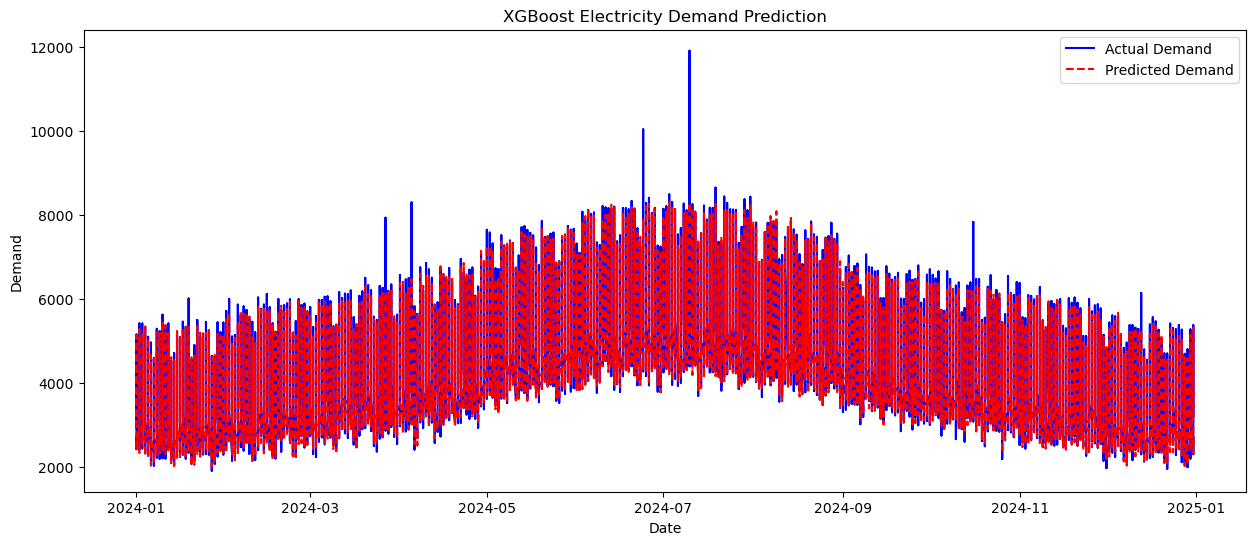

In [80]:
# Visulaize the Predictions

plt.figure(figsize = (15,6))
plt.plot(Y_test.index, Y_test, label = 'Actual Demand', color = 'Blue')
plt.plot(Y_test.index, predictions_xgb, label = 'Predicted Demand', color = 'Red', linestyle='--')
plt.title('XGBoost Electricity Demand Prediction')
plt.xlabel('Date')
plt.ylabel('Demand')
plt.legend()

plt.show()

In [93]:
# save the model

import joblib

joblib.dump(model_xgb, 'electricity_xgb_prediction_model.pkl')

['electricity_xgb_prediction_model.pkl']

In [94]:
import os
print(os.listdir())

['-1.14-windows.xml', '.anaconda', '.arduinoIDE', '.bash_history', '.cache', '.conda', '.condarc', '.continuum', '.gitconfig', '.idea', '.ipynb_checkpoints', '.ipython', '.jupyter', '.matplotlib', '.vscode', 'anaconda3', 'anaconda_projects', 'AppData', 'Application Data', 'Contacts', 'Cookies', 'denoise-demo', 'Desktop', 'Documents', 'Downloads', 'ElecDemand Proj', 'Electricity Demand Forecasting.ipynb', 'electricity_xgb_prediction_model.pkl', 'Favorites', 'Links', 'Local Settings', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{fad4830d-4b6a-11f0-aa44-00e04c360083}.TM.blf', 'NTUSER.DAT{fad4830d-4b6a-11f0-aa44-00e04c360083}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{fad4830d-4b6a-11f0-aa44-00e04c360083}.TMContainer00000000000000000002.regtrans-ms', 'ntuser.ini', 'Numpy', 'OneDrive', 'Pictures', 'Postman', 'PrintHood', 'PycharmProjects', 'Recent', 'Saved Games', 'Searches', 'SendTo', 'Sentiment analysis', 'Start Menu', 

In [96]:
loaded_model = joblib.load(r'C:\Users\tusha\Desktop\ML\project elec demand\electricity_xgb_prediction_model.pkl')

In [97]:
loaded_model

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=50,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.01, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)

In [99]:
import pandas as pd
import joblib

# load model
model = joblib.load('electricity_xgb_prediction_model.pkl')

sample_input = pd.DataFrame({
    'hour':[18],
    'dayofweek':[4],
    'month':[7],
    'year':[2025],
    'dayofyear':[200],
    'weekofyear':[29],
    'quarter':[3],
    'is_weekend':[0],
    'Temperature':[32],
    'Humidity':[60],
    'Demand_lag_24hr':[420],
    'demand_lag_168hr':[410],
    'demand_rolling_mean_24hr':[415],
    'demand_rolling_std_24hr':[12]
})

prediction = model.predict(sample_input)

print("Predicted Electricity Demand:", prediction[0])

Predicted Electricity Demand: 4176.668
